# Autoencoder
This notebook makes use of the **Autoencoder**, which is used to reduce the dimensionality of our dataset in a non-linear way. Furthermore, we then apply **k-means Clustering** as in our last notebook in our new created **Latent Space** in lower dimension. We do so, to get rid of less important variables and achieve a better Clustering.

In [1]:
!pip install -q -r ../../requirements.txt &> /dev/null

In [17]:
import importlib
from ipywidgets import FloatSlider
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from ipywidgets import interact, IntSlider
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

import sys
sys.path.append("../..")
import helper_functions
importlib.reload(helper_functions)

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore", message="Degrees of freedom <= 0 for slice")


## The Architecture

In [3]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout):
        super().__init__()

        # Encoder for mean and logvar
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.LeakyReLU(),

            nn.Linear(512, 32),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout),
            nn.LeakyReLU()
        )
        self.fc_mean = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),

            nn.Linear(32, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),

            nn.Linear(512, input_dim)
        )

    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def forward(self, x):
        h = self.encoder(x)
        z_mean = self.fc_mean(h)
        z_logvar = self.fc_logvar(h)
        z = self.reparameterize(z_mean, z_logvar)
        x_recon = self.decoder(z)
        return x_recon, z_mean, z_logvar

## Data Loading & Preprocessing

In [4]:
trend_removal = False

In [18]:
ds = xr.open_dataset("../../data/medsea1987to2025_train.nc")

z_temp = helper_functions.preprocessing(ds, ["thetao", "so"], [50, 300, 1000], "location", trend_removal, 1)
X = z_temp.values
input_dimension = X.shape[1]

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VariationalAutoencoder(input_dim=input_dimension, latent_dim=3, dropout=0.2).to(device)
model.load_state_dict(torch.load("../models/VAE.pth", weights_only=False))

<All keys matched successfully>

## Reconstructing
Before we do any Clustering, let's see how good the model is in reconstructing one sample.

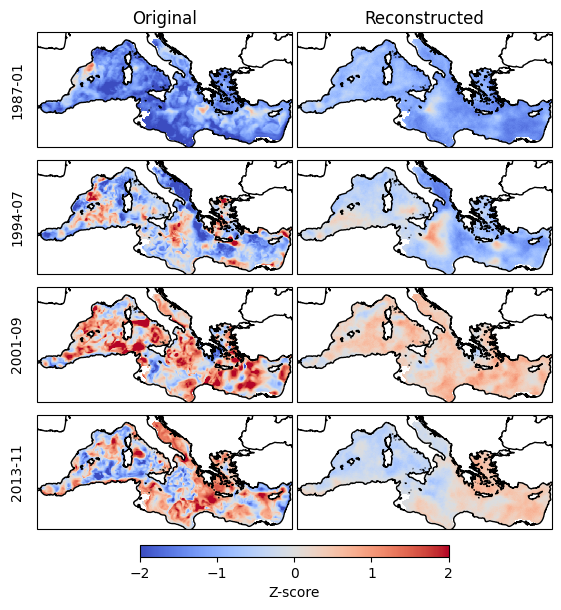

In [21]:
original_z = helper_functions.preprocessing(ds, ["thetao"], [50], "location", trend_removal, 1)

X_recon_all = helper_functions.reconstruct_in_batches(X, model, device, 64)
coords = original_z.location
reconstructed_z = helper_functions.reconstructed_to_stack(ds, "thetao", 50, X_recon_all, coords)

helper_functions.plot_reconstruction_comparison(
    z_stack_original=original_z,
    z_stack_recon=reconstructed_z,
    time_indices=[0, 90, 176, 322],
    cmin=-2,
    cmax=2
)

## Clustering with K-Means, K = 9

VAE


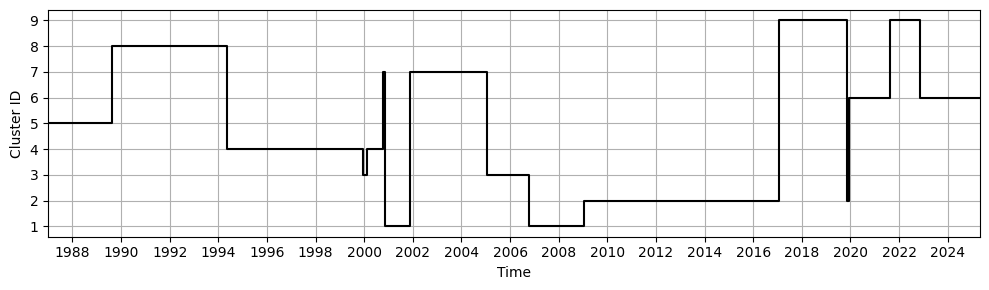

In [11]:
latents, labels = helper_functions.get_latents_and_cluster(model, X, 9)

helper_functions.plot_cluster_timeline(z_temp, labels)

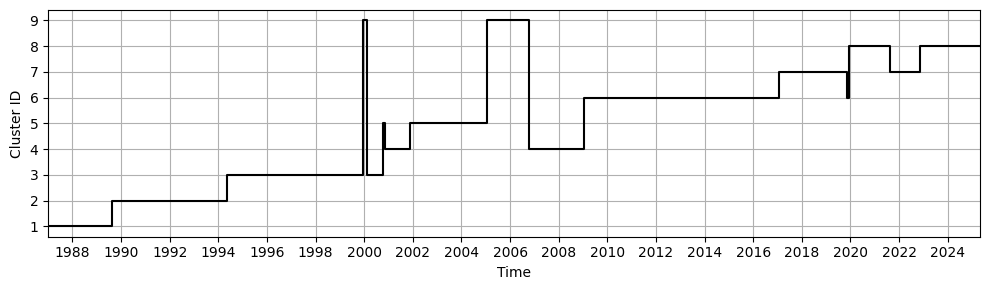

In [12]:
path = "hungarian"
kmeans_series = helper_functions.load_clusterseries(path, "kmeans_9clusters.npy")
_, permutation = helper_functions.find_best_permutation(kmeans_series, labels, 9)
labels = np.array([permutation[k] for k in labels])

helper_functions.plot_cluster_timeline(z_temp, labels)

### Calculating the MSE Loss per Cluster

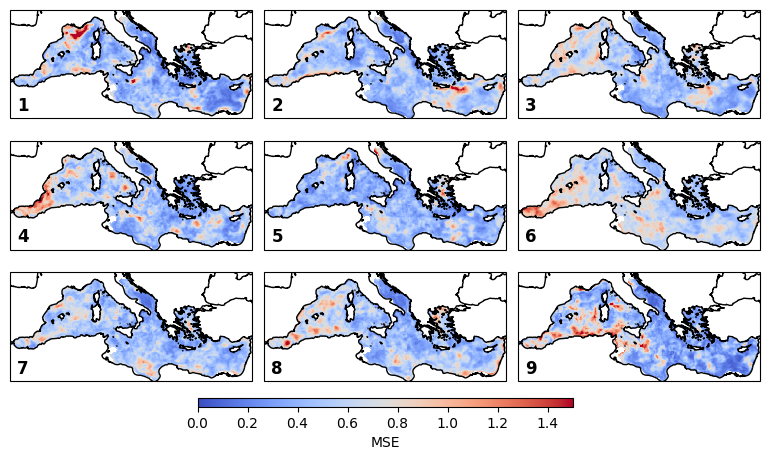

In [13]:
helper_functions.plot_average_loss_map_from_data(original_z, reconstructed_z, labels, 0, 1.5)

### Depth = 50

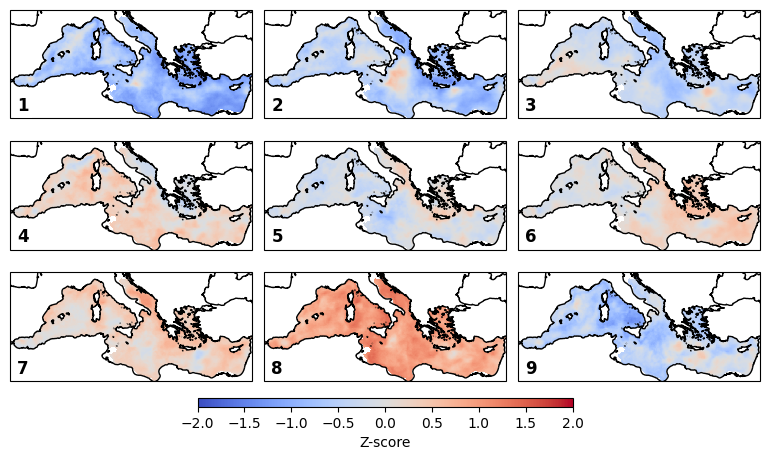

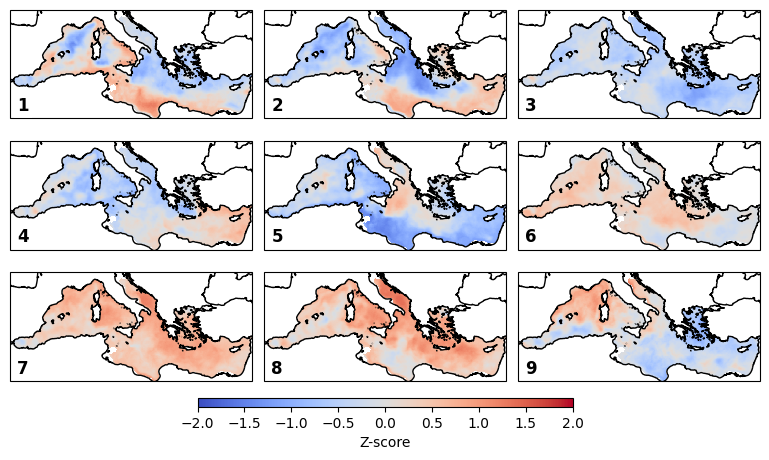

In [14]:
recon_temp_50 = helper_functions.reconstructed_to_stack(ds, "thetao", 50, X_recon_all, coords)
helper_functions.plot_average_cluster(recon_temp_50, labels, -2, 2)

recon_so_50 = helper_functions.reconstructed_to_stack(ds, "so", 50, X_recon_all, coords)
helper_functions.plot_average_cluster(recon_so_50, labels, -2, 2)

### Depth = 300

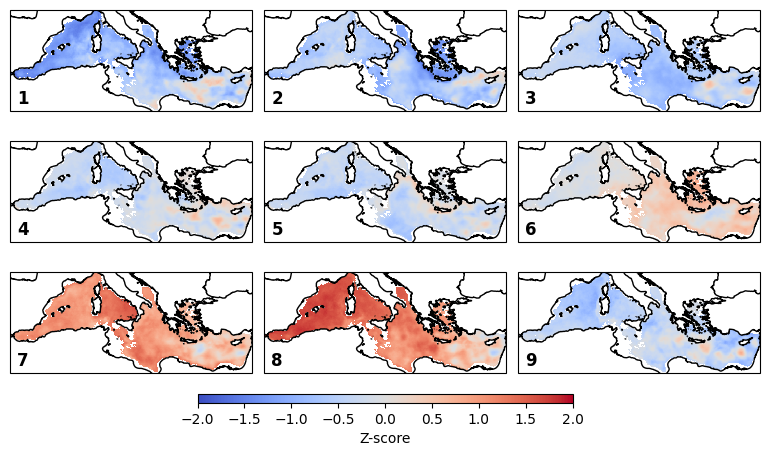

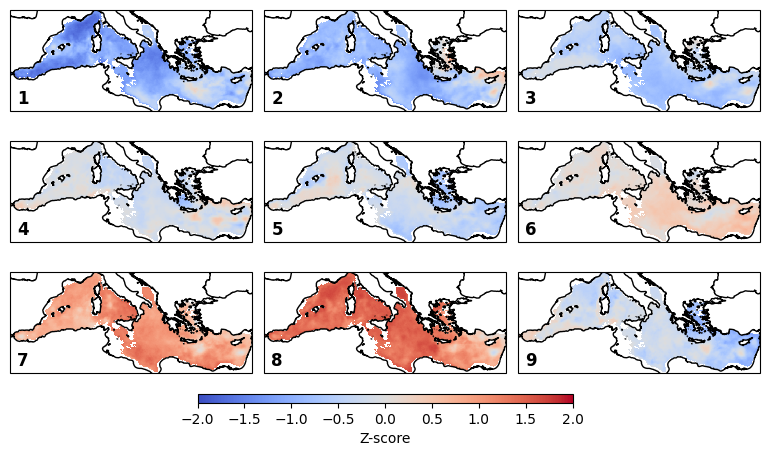

In [22]:
coords = helper_functions.preprocessing(ds, ["thetao"], [300], "location", trend_removal, 1).location
recon_temp_300 = helper_functions.reconstructed_to_stack(ds, "thetao", 300, X_recon_all, coords)
helper_functions.plot_average_cluster(recon_temp_300, labels, -2, 2)

recon_so_300 = helper_functions.reconstructed_to_stack(ds, "so", 300, X_recon_all, coords)
helper_functions.plot_average_cluster(recon_so_300, labels, -2, 2)

### Depth = 1000

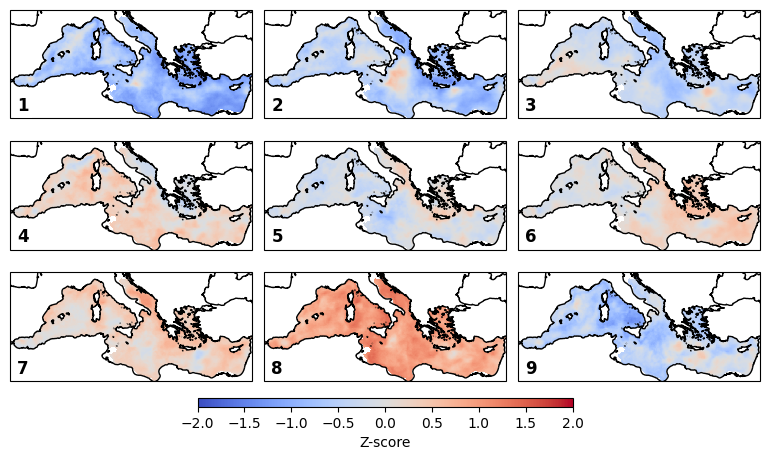

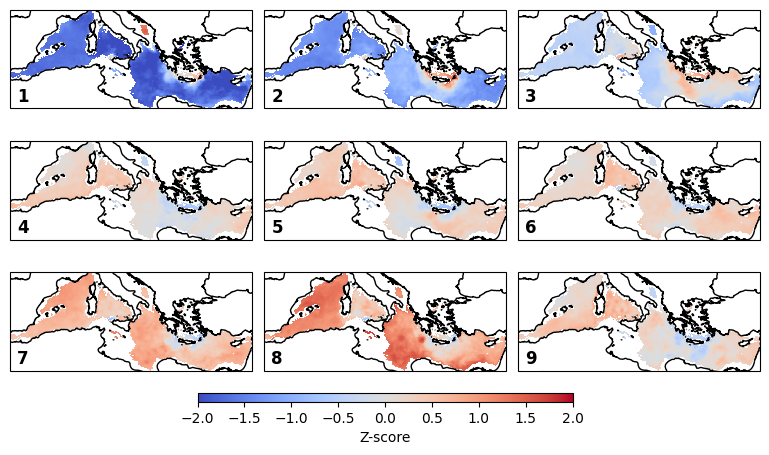

In [23]:
coords = helper_functions.preprocessing(ds, ["thetao"], [1000], "location", trend_removal, 1).location
recon_temp_1000 = helper_functions.reconstructed_to_stack(ds, "thetao", 1000, X_recon_all, coords)
helper_functions.plot_average_cluster(recon_temp_50, labels, -2, 2)

recon_so_1000 = helper_functions.reconstructed_to_stack(ds, "so", 1000, X_recon_all, coords)
helper_functions.plot_average_cluster(recon_so_1000, labels, -2, 2)